# Avaliação 01 - CNN

- Base Escolhida: Intel Image Classification disponível no Kaggle https://www.kaggle.com/datasets/puneet6060/intel-image-classification
- Selecionar um modelo pré-treinado para comparação
- Desenvolver um modelo baseline baseado nos requisitos
- Experimentar tuning de hiperparâmetros e regularização para melhorar a performance

In [159]:
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import SGD  # Stochastic Gradient Descent
import keras_tuner

from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

import numpy as np
import random

RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

tf.config.list_physical_devices('GPU')

[]

In [160]:
categories = {
    'buildings': 0,
    'forest': 1,
    'glacier': 2,
    'mountain': 3,
    'sea': 4,
    'street': 5
}

## Carregar imagens e fazer o resize para que as dimensoes estejam batendo

In [161]:
def load_images_from_subfolders(parent_folder):
    image_data = []
    labels = []

    for folder_name in os.listdir(parent_folder):
        subfolder_path = os.path.join(parent_folder, folder_name)
        if os.path.isdir(subfolder_path):
            for image_file in os.listdir(subfolder_path):
                image_path = os.path.join(subfolder_path, image_file)
                
                try:
                    # Open image and convert to RGB (optional)
                    # img = Image.open(image_path).convert('RGB')
                    img = Image.open(image_path)
                    img = img.resize((150, 150))
                    
                    img_array = np.array(img)
                    
                    image_data.append(img_array)
                    labels.append(folder_name)
                except Exception as e:
                    print(f"Error loading image {image_file}: {e}")
    
    for index, image in enumerate(image_data):
        if image.shape != (150, 150, 3):
            print(image.shape)
            image_data.pop(index)
            labels.pop(index)
    image_data = np.array(image_data)
    labels = np.array(labels)
    
    if len(image_data) != len(labels):
        raise ValueError("Image Data and Labels are not the same length")
    return image_data, labels

def label_encode(label_array):
    for i in range(len(label_array)):
        label_array[i] = int(categories[label_array[i]])
    label_array = label_array.astype(int)
    print(label_array[:5])
    print(type(label_array[0]))
    print(label_array.shape)
    return label_array


In [162]:
# Example usage:
train_folder = 'av01_cnn/data/seg_train/'
train_image_data, train_labels = load_images_from_subfolders(train_folder)

# Check the shape of the first image array and its label
print(f"Shape of first image array: {train_image_data[0].shape}")
print(f"First image label: {train_labels[0]}")

Shape of first image array: (150, 150, 3)
First image label: forest


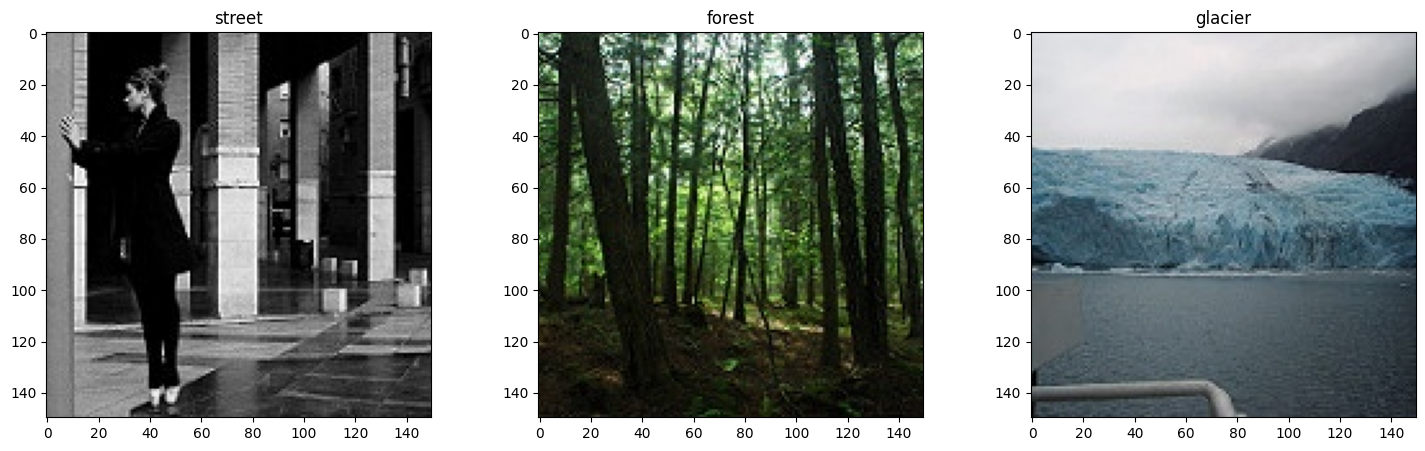

In [163]:
plt.figure(figsize=(18, 5))
for i in range(3):
    random_index = np.random.randint(len(train_image_data))
    plt.subplot(1, 3, i+1)
    plt.axis(True)
    plt.imshow(train_image_data[random_index])
    plt.title(train_labels[random_index])
    plt.subplots_adjust(wspace=0.2, hspace=0.2)

In [164]:
# for i in range(len(train_labels)):
#     train_labels[i] = categories[train_labels[i]]
# print(train_labels[:5])
# print(train_labels.shape)

train_labels = label_encode(train_labels)

[1 1 1 1 1]
<class 'numpy.int64'>
(14034,)


In [165]:
print(train_image_data.shape)

(14034, 150, 150, 3)


In [166]:
test_folder = 'av01_cnn/data/seg_test/'
test_image_data, test_labels = load_images_from_subfolders(test_folder)
test_labels = label_encode(test_labels)

[1 1 1 1 1]
<class 'numpy.int64'>
(3000,)


## Modelo Baseline

In [167]:
early_stopping = EarlyStopping(
    monitor='val_accuracy', 
    patience=12,
    restore_best_weights=True
)

def instantiate_baseline_model():
	model = Sequential()
	model.add(Conv2D(32, (3, 3), activation='tanh', input_shape=test_image_data[0].shape))
	model.add(MaxPooling2D((2, 2)))
	model.add(Conv2D(32, (3, 3), activation='tanh'))
	model.add(MaxPooling2D((2, 2)))
	model.add(Conv2D(32, (3, 3), activation='tanh'))
	model.add(MaxPooling2D((2, 2)))
	model.add(Flatten())
	model.add(Dense(100, activation='tanh'))
	model.add(Dense(6, activation='softmax'))
	# compile model
	opt = SGD(learning_rate=0.01)
	model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

	return model

In [168]:
baseline_model = instantiate_baseline_model()
baseline_model.summary()

/usr/local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_29 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 72, 72, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 36, 36, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 34, 34, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │       924,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 944,898 (3.60 MB)

 Trainable params: 944,898 (3.60 MB)

 Non-trainable params: 0 (0.00 B)

In [169]:
# one hot encode output
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

In [170]:
baseline_train_res = baseline_model.fit(
    train_image_data,
    y_train,
    epochs=120,
    batch_size=128,
    validation_data=(test_image_data, y_test),
    callbacks=[early_stopping]
)

Epoch 1/120
110/110 ━━━━━━━━━━━━━━━━━━━━ 144s 1s/step - accuracy: 0.3922 - loss: 1.6140 - val_accuracy: 0.3810 - val_loss: 1.5160
Epoch 2/120
110/110 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.5650 - loss: 1.0930 - val_accuracy: 0.4197 - val_loss: 1.5443
Epoch 3/120
 44/110 ━━━━━━━━━━━━━━━━━━━━ 1:19 1s/step - accuracy: 0.5601 - loss: 1.1049